In [1]:
import math
import random
from dataclasses import dataclass

import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch,torchvision
import numpy as np
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, Subset
import os
import random
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
import time
from typing import Tuple, Dict, List, Optional
import math
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
RANDOM=42

root= ".data/"
atrtifacts_folder= "artifacts/"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 256 if device.type == "cuda" else 64
print(device)
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

cuda


In [2]:
df = pd.read_csv("S12-hw-dataset.csv")
df.head()

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62


In [3]:
df["date"] = pd.to_datetime(df["date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4320 entries, 0 to 4319
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    4320 non-null   datetime64[ns]
 1   target  4320 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 67.6 KB


In [4]:
df.sort_values("date")
df.describe()


,date,target
count,4320,4320.000000
mean,2025-03-31 23:29:59.999999744,135.605840
min,2025-01-01 00:00:00,69.100000
25%,2025-02-14 23:45:00,120.537500
50%,2025-03-31 23:30:00,135.835000
75%,2025-05-15 23:15:00,150.625000
max,2025-06-29 23:00:00,210.100000
std,NaN,21.384633


In [5]:
df.value_counts(dropna=False)

date                 target
2025-01-01 00:00:00  98.14     1
2025-01-01 01:00:00  98.07     1
2025-01-01 02:00:00  104.70    1
2025-01-01 03:00:00  112.81    1
2025-01-01 04:00:00  112.62    1
                              ..
2025-06-29 19:00:00  153.05    1
2025-06-29 20:00:00  134.23    1
2025-06-29 21:00:00  137.68    1
2025-06-29 22:00:00  126.53    1
2025-06-29 23:00:00  120.89    1
Name: count, Length: 4320, dtype: int64

C:\Users\study\AppData\Local\Temp\ipykernel_2600\2868624198.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


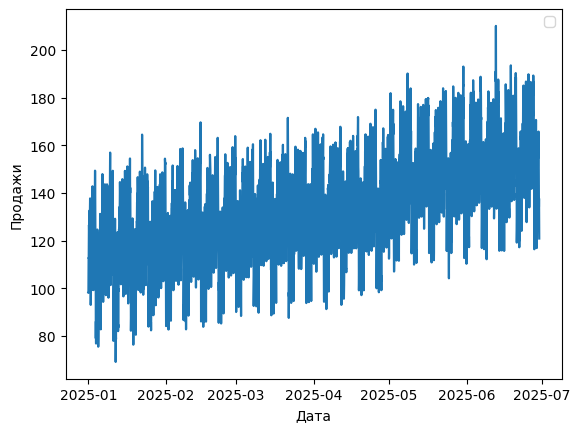

In [ ]:
fig, ax = plt.subplots()
ax.plot(df["date"], df["target"], lw=1.6, )
ax.set_xlabel("Дата")
ax.legend()
plt.show()

In [7]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    # Проверяем, что доли действительно покрывают весь датасет.
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    # Ключевая идея: train, validation и test идут по времени друг за другом.
    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)
print(f"train: {train_df['date'].min().date()} → {train_df['date'].max().date()} | {len(train_df)} строк")
print(f"val:   {val_df['date'].min().date()} → {val_df['date'].max().date()} | {len(val_df)} строк")
print(f"test:  {test_df['date'].min().date()} → {test_df['date'].max().date()} | {len(test_df)} строк")

train: 2025-01-01 → 2025-05-06 | 3024 строк
val:   2025-05-07 → 2025-06-02 | 648 строк
test:  2025-06-03 → 2025-06-29 | 648 строк


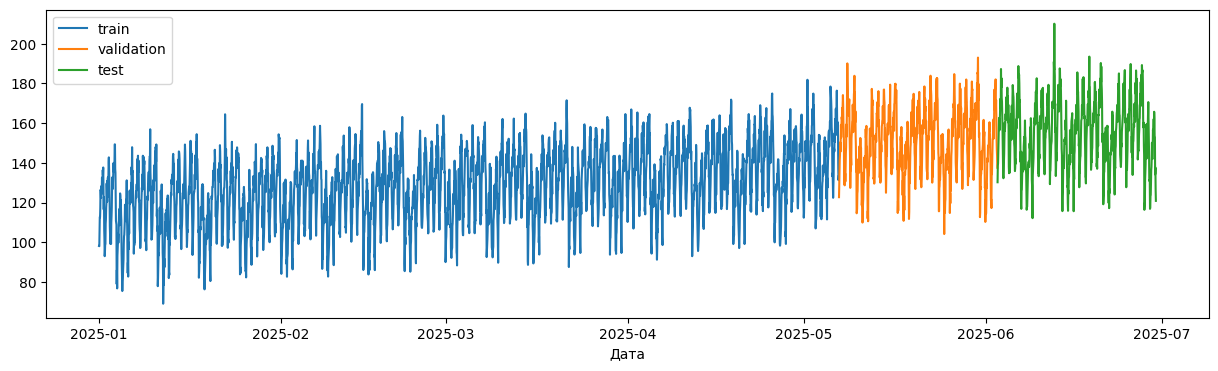

In [8]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(train_df["date"], train_df["target"], label="train")
ax.plot(val_df["date"], val_df["target"], label="validation")
ax.plot(test_df["date"], test_df["target"], label="test")

ax.set_xlabel("Дата")

ax.legend()
plt.savefig(atrtifacts_folder+"figures/series_split.png")
plt.show()


random_split не применим тк теряется зависимость от времени.

In [9]:
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Календарные признаки часто дают модели простую и полезную сезонную структуру.
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month

    # Синус/косинус кодируют цикличность без искусственного разрыва между концом и началом периода.
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)

    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    out = df.copy()

    # Лаги смотрят только назад во времени и поэтому безопасны с точки зрения leakage.
    for lag in [1, 2, 3, 7, 14, 28]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)

    # Перед rolling используем shift(1), чтобы статистика не включала текущее наблюдение.
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    out["rolling_mean_28"] = out[target_col].shift(1).rolling(window=28).mean()
    out["rolling_std_28"] = out[target_col].shift(1).rolling(window=28).std()
    return out


features_df = add_calendar_features(df)
print(features_df)
features_df = add_lag_features(features_df)
features_df = features_df.dropna().reset_index(drop=True)
features_df.head()
 


                    date  target  dayofweek  month   dow_sin   dow_cos  \
0    2025-01-01 00:00:00   98.14          2      1  0.974928 -0.222521   
1    2025-01-01 01:00:00   98.07          2      1  0.974928 -0.222521   
2    2025-01-01 02:00:00  104.70          2      1  0.974928 -0.222521   
3    2025-01-01 03:00:00  112.81          2      1  0.974928 -0.222521   
4    2025-01-01 04:00:00  112.62          2      1  0.974928 -0.222521   
...                  ...     ...        ...    ...       ...       ...   
4315 2025-06-29 19:00:00  153.05          6      6 -0.781831  0.623490   
4316 2025-06-29 20:00:00  134.23          6      6 -0.781831  0.623490   
4317 2025-06-29 21:00:00  137.68          6      6 -0.781831  0.623490   
4318 2025-06-29 22:00:00  126.53          6      6 -0.781831  0.623490   
4319 2025-06-29 23:00:00  120.89          6      6 -0.781831  0.623490   

         month_sin  month_cos  
0     5.000000e-01   0.866025  
1     5.000000e-01   0.866025  
2     5.000000e

,date,target,dayofweek,month,dow_sin,dow_cos,month_sin,month_cos,lag_1,lag_2,lag_3,lag_7,lag_14,lag_28,rolling_mean_7,rolling_std_7,rolling_mean_28,rolling_std_28
0,2025-01-02 04:00:00,111.64,3,1,0.433884,-0.900969,0.5,0.866025,109.33,99.14,99.05,106.54,128.87,98.14,100.545714,5.856307,116.487143,13.778753
1,2025-01-02 05:00:00,117.30,3,1,0.433884,-0.900969,0.5,0.866025,111.64,109.33,99.14,101.72,136.40,98.07,101.274286,6.942790,116.969286,13.342257
2,2025-01-02 06:00:00,119.72,3,1,0.433884,-0.900969,0.5,0.866025,117.30,111.64,109.33,93.04,133.85,104.70,103.500000,9.230043,117.656071,12.818023
3,2025-01-02 07:00:00,129.68,3,1,0.433884,-0.900969,0.5,0.866025,119.72,117.30,111.64,95.00,137.71,112.81,107.311429,9.688052,118.192500,12.567579
4,2025-01-02 08:00:00,124.85,3,1,0.433884,-0.900969,0.5,0.866025,129.68,119.72,117.30,99.05,126.32,112.62,112.265714,11.106433,118.795000,12.703625


In [10]:
# Собираем финальный набор признаков для baseline-моделей.
feature_cols = [
    "dayofweek", "month",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_28", "rolling_std_28",
]

target_col = "target"

# Разбиение выполняем после построения признаков, но без перемешивания по времени.
train_feat, val_feat, test_feat = temporal_split(features_df)

X_train = train_feat[feature_cols]
y_train = train_feat[target_col]

X_val = val_feat[feature_cols]
y_val = val_feat[target_col]

X_test = test_feat[feature_cols]
y_test = test_feat[target_col]

print("Размерности:")
print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "| y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "| y_test: ", y_test.shape)

Размерности:
X_train: (3004, 16) | y_train: (3004,)
X_val:   (644, 16) | y_val:   (644,)
X_test:  (644, 16) | y_test:  (644,)


In [11]:
@torch.no_grad()
def predict_model(model, loader, device):
    """
    Получает предсказания модели на батчах.
    Возвращает предсказания и истинные значения (в масштабированном пространстве).
    """
    model.eval()
    preds = []
    targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch).detach().cpu().numpy()  # Переводим в numpy
        preds.append(outputs)
        targets.append(y_batch.numpy())

    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    return preds, targets


def inverse_scale(values_1d: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    """Преобразует нормализованные значения обратно в исходный масштаб."""
    return scaler.inverse_transform(values_1d.reshape(-1, 1)).ravel()


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """
    Вычисляет три основные метрики для регрессии:
    - MAE (Mean Absolute Error): средняя абсолютная ошибка в исходном масштабе
    - RMSE (Root Mean Squared Error): корень из среднеквадратичной ошибки
    - MAPE (Mean Absolute Percentage Error): средняя абсолютная процентная ошибка (%)
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-8, None))) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}

def clear():
    f = open(atrtifacts_folder+"runs.csv","w")
    f.write('')
    f.close()

def log_csv( id:str ,
            task:str,
            dataset:str,
            seed:int,
            split_summary,
            window_size,
            horizon,
            model_summary,
            features_summary,
            scaler,
            optimizer:str,
            lr,
            history,
            best_val_mae,
            best_val_rmse,
            best_val_mape,
             notes="",
             test_mae="none", test_rmse="none", test_mape="none"):

    df= pd.DataFrame({"experiment_id":[id],"task":[task], "dataset":[dataset],"seed":[seed],"model_summary":[model_summary],"optimizer":[optimizer],"lr":[lr],"epochs_trained":[len(history["train_loss"])],"split_summary":[split_summary], "window_size":[window_size], "horizon":[horizon], "features_summary":features_summary, "scaler":[scaler], "test_mae":[test_mae], "test_rmse":[test_rmse], "test_mape":[test_mape], "best_val_mae":[best_val_mae],"best_val_rmse":[best_val_rmse],"best_val_mape":[best_val_mape],"notes":[notes]},columns=["experiment_id","task", "dataset","seed","model_summary","optimizer","lr","epochs_trained","split_summary", "window_size", "horizon", "features_summary", "scaler", "test_mae", "test_rmse", "test_mape", "best_val_mae","best_val_rmse","best_val_mape","notes"],index=None)
    try:
        df.to_csv(atrtifacts_folder+"runs.csv",header=(True if os.path.getsize(atrtifacts_folder+"runs.csv")==0 else None),index=None, mode="a")
    except:
        df.to_csv(atrtifacts_folder+"runs.csv",header=True,index=None, mode="a")


In [12]:
clear()

## B1

In [13]:
# Naive baseline: завтрашнее значение равно последнему наблюдённому.
val_pred_naive = val_feat["lag_1"].to_numpy()
test_pred_naive = test_feat["lag_1"].to_numpy()



baseline_results_val =regression_metrics(y_val, val_pred_naive),
    


#baseline_results_test = regression_metrics(y_test, test_pred_naive),
    

print("Validation:")
display(baseline_results_val)
log_csv("B1","forecasting","S12-hw-dataset.csv",RANDOM,"train_frac: float = 0.70 val_frac: float = 0.15 test_frac: float = 0.15","none",1,"naive baseline","lag_1","none","none","none",{"train_loss":[]},baseline_results_val[0]["MAE"],baseline_results_val[0]["RMSE"],baseline_results_val[0]["MAPE"],"")
#print("Test:")
#display(baseline_results_test)
val_pred_naive.shape

Validation:


({'MAE': 6.44111801242236,
  'RMSE': 8.207077766528016,
  'MAPE': np.float64(4.393620013429696)},)

(644,)

## B2

In [14]:
# Moving average baseline: вместо одного прошлого значения берём короткое среднее окно.
val_pred_ma7 = val_feat["rolling_mean_7"].to_numpy()
test_pred_ma7 = test_feat["rolling_mean_7"].to_numpy()
baseline_results_val=regression_metrics(y_val, val_pred_ma7)
baseline_results_test=regression_metrics(y_test, test_pred_ma7)

print("Validation:")
display(baseline_results_val)

log_csv("B2","forecasting","S12-hw-dataset.csv",RANDOM,"train_frac: float = 0.70 val_frac: float = 0.15 test_frac: float = 0.15","7",1,"moving avrerage baseline","rolling_mean_7","none","none","none",{"train_loss":[]},baseline_results_val["MAE"],baseline_results_val["RMSE"],baseline_results_val["MAPE"],"")

Validation:


{'MAE': 12.697559893522625,
 'RMSE': 15.226532805400108,
 'MAPE': np.float64(8.812577344433095)}

## B3

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32) 
X_val_scaled = scaler.transform(X_val).astype(np.float32) 
X_test_scaled = scaler.transform(X_test).astype(np.float32) 

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
val_pred_ridge = ridge.predict(X_val_scaled)

val_results= regression_metrics(y_val, val_pred_ridge)
print("Validation:")
display(val_results)

#print("Test:")
#display(test_results)
log_csv("B3","forecasting","S12-hw-dataset.csv",RANDOM,"train_frac: float = 0.70 val_frac: float = 0.15 test_frac: float = 0.15","none",1,"Ridge"," dayofweek, month,dow_sin, dow_cos,month_sin, month_cos,lag_1, lag_2, lag_3, lag_7, lag_14, lag_28,rolling_mean_7, rolling_std_7, rolling_mean_28, rolling_std_28   ","StandartScaler","none","none",{"train_loss":[]},val_results["MAE"],val_results["RMSE"],val_results["MAPE"],"")

Validation:


{'MAE': 5.139289359809449,
 'RMSE': 6.5908721936777415,
 'MAPE': np.float64(3.449632176351384)}

## R1

In [16]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["target"]]).astype(np.float32)  # fit на train
val_scaled = scaler.transform(val_df[["target"]]).astype(np.float32)          # transform для val/test
test_scaled = scaler.transform(test_df[["target"]]).astype(np.float32)

window_size = 28  # Глубина контекста: модель смотрит на 28 дней в прошлое

def make_windows(series_2d: np.ndarray, window_size: int):
    """
    Преобразует временной ряд в обучающие примеры вида (X, y).
    Каждый пример X: окно из window_size значений
    Каждый пример y: следующее значение после окна
    Например: X = [day1..day28], y = day29
    """
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])        # Окно длины 28
        y.append(series_2d[i + window_size, 0])         # Цель: день 29
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
X_train_w, y_train_w = make_windows(train_scaled, window_size)
X_val_w, y_val_w = make_windows(val_scaled, window_size)
X_test_w, y_test_w = make_windows(test_scaled, window_size)

print("X_train:", X_train_w.shape, "y_train:", y_train_w.shape)
print("X_val  :", X_val_w.shape, "y_val  :", y_val_w.shape)
print("X_test :", X_test_w.shape, "y_test :", y_test_w.shape)

X_train: (2996, 28, 1) y_train: (2996,)
X_val  : (620, 28, 1) y_val  : (620,)
X_test : (620, 28, 1) y_test : (620,)


In [17]:

class TimeSeriesDataset(Dataset):
    """Оборачивает массивы X, y в PyTorch Dataset для использования с DataLoader."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)  # (num_samples, window_size, 1)
        self.y = torch.tensor(y, dtype=torch.float32)  # (num_samples,)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

batch_size = 64  # Размер батча для градиентного спуска

# Создаем датасеты для каждого набора
train_ds = TimeSeriesDataset(X_train_w, y_train_w)
val_ds = TimeSeriesDataset(X_val_w, y_val_w)
test_ds = TimeSeriesDataset(X_test_w, y_test_w)

# Создаем DataLoaders для итерирования по батчам
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)   # train перемешиваем
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)      # val не перемешиваем
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [18]:
class GRUForecaster(nn.Module):
    """
    GRU-модель для временных рядов.
    GRU проще, чем LSTM: имеет 2 вентиля (reset и update) вместо 3, нет cell state.
    Часто работает лучше на малых датасетах благодаря меньшей сложности оптимизации.
    """
    def __init__(self, input_size: int = 1, hidden_size: int = 48, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred
    
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    Обучает модель на одной эпохе.
    1. Переводим в режим train
    2. Проходим по всем батчам
    3. Вычисляем loss и обновляем веса
    4. Возвращаем среднее значение loss
    """
    model.train()  # Режим обучения (включающий dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()           # Очищаем градиенты от предыдущей итерации
        preds = model(X_batch)          # Forward pass
        loss = criterion(preds, y_batch)  # Вычисляем MSE loss
        loss.backward()                 # Backward pass: вычисляем градиенты
        optimizer.step()                # Обновляем веса по градиентам

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """
    Оценивает модель на валидации/тесте без обновления весов.
    @torch.no_grad() отключает вычисление градиентов (экономит память и время).
    """
    model.eval()  # Режим оценки (отключаем dropout, batch norm и т.д.)
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))


def fit_model(model, train_loader, val_loader, epochs=12, lr=1e-3, device=device):
    """
    Полный цикл обучения с ранней остановкой.
    Сохраняет лучшее состояние модели (когда val_loss был минимален).
    """
    criterion = nn.MSELoss()  # Mean Squared Error loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        # 1. Обучение на train
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        # 2. Оценка на validation
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        # 3. Отслеживаем лучший результат
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()  # Сохраняем веса при лучшем val_loss

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    # 4. Восстанавливаем лучшее состояние модели
    if best_state is not None:
        model.load_state_dict(best_state)

    return history

In [19]:
set_seed(42)
gru_model = GRUForecaster(hidden_size=64, num_layers=2).to(device)
print("GRU  params:", sum(p.numel() for p in gru_model.parameters()))
gru_history = fit_model(gru_model, train_loader, val_loader, epochs=30, lr=5e-4, device=device)

GRU  params: 37889
Epoch 01 | train_loss=0.7695 | val_loss=0.6465
Epoch 02 | train_loss=0.4325 | val_loss=0.3439
Epoch 03 | train_loss=0.2172 | val_loss=0.1883
Epoch 04 | train_loss=0.1698 | val_loss=0.1741
Epoch 05 | train_loss=0.1597 | val_loss=0.1704
Epoch 06 | train_loss=0.1556 | val_loss=0.1707
Epoch 07 | train_loss=0.1533 | val_loss=0.1720
Epoch 08 | train_loss=0.1517 | val_loss=0.1734
Epoch 09 | train_loss=0.1505 | val_loss=0.1745
Epoch 10 | train_loss=0.1494 | val_loss=0.1754
Epoch 11 | train_loss=0.1483 | val_loss=0.1759
Epoch 12 | train_loss=0.1470 | val_loss=0.1762
Epoch 13 | train_loss=0.1454 | val_loss=0.1763
Epoch 14 | train_loss=0.1435 | val_loss=0.1761
Epoch 15 | train_loss=0.1408 | val_loss=0.1759
Epoch 16 | train_loss=0.1360 | val_loss=0.1744
Epoch 17 | train_loss=0.1265 | val_loss=0.1608
Epoch 18 | train_loss=0.1147 | val_loss=0.1654
Epoch 19 | train_loss=0.1090 | val_loss=0.1697
Epoch 20 | train_loss=0.1067 | val_loss=0.1689
Epoch 21 | train_loss=0.1051 | val_loss=0

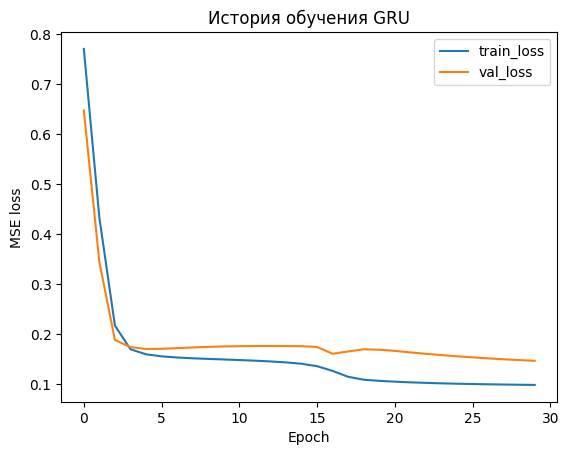

In [20]:
fig, ax = plt.subplots()
ax.plot(gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["val_loss"], label="val_loss")
ax.set_title("История обучения GRU")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
plt.savefig(atrtifacts_folder+"figures/gru_learning_curves.png")
plt.show()



In [21]:


# Получаем предсказания всех трех моделей на validation

gru_val_pred_scaled, gru_val_true_scaled = predict_model(gru_model, val_loader, device)

# Восстанавливаем исходный масштаб
gru_val_pred = inverse_scale(gru_val_pred_scaled, scaler)

# Вычисляем метрики для каждой модели и сортируем по RMSE
val_metrics = pd.DataFrame(
    [
        {"model": "Naive baseline", **regression_metrics(y_val, val_pred_naive)},
        {"model": "Moving average baseline", **regression_metrics(y_val, val_pred_ma7)},
        {"model": "Ridge", **regression_metrics(y_val, val_pred_ridge)},
        {"model": "GRU", **regression_metrics(y_val[:-window_size+4], gru_val_pred)},
    ]
).sort_values("RMSE")
log_csv("R1","forecasting","S12-hw-dataset.csv",RANDOM,"train_frac: float = 0.70 val_frac: float = 0.15 test_frac: float = 0.15",window_size,1,"GRU","hidden_size=64, num_layers=2","StandartScaler","Adam",5e-4,gru_history,baseline_results_val["MAE"],baseline_results_val["RMSE"],baseline_results_val["MAPE"],"")
val_metrics

,model,MAE,RMSE,MAPE
2,Ridge,5.139289,6.590872,3.449632
0,Naive baseline,6.441118,8.207078,4.393620
1,Moving average baseline,12.697560,15.226533,8.812577
3,GRU,15.110661,18.816269,10.354605


Лучшая модель на val: Ridge


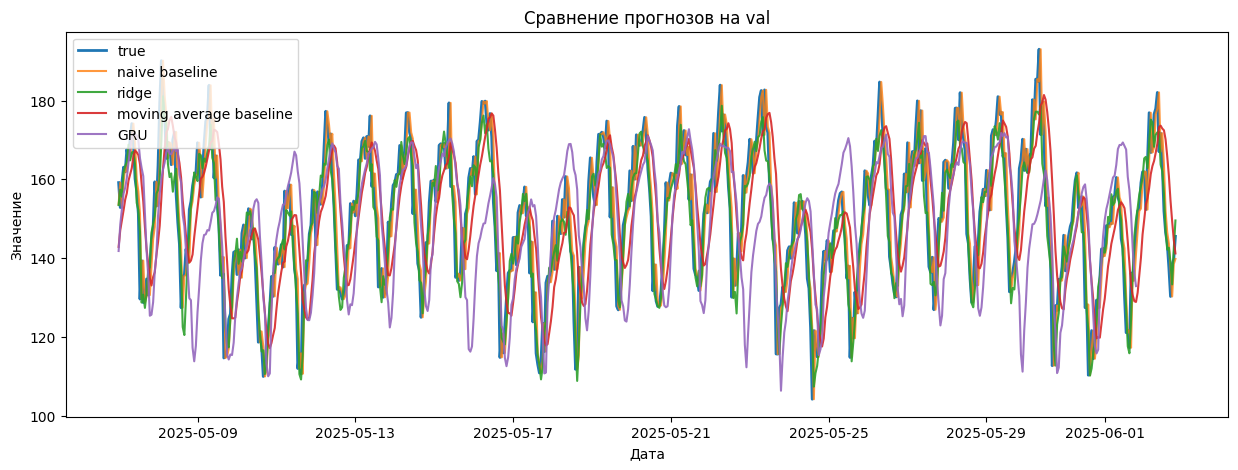

In [22]:
best_model_name = val_metrics.iloc[0]["model"]
print("Лучшая модель на val:", best_model_name)
torch.save(gru_model.state_dict(),atrtifacts_folder+"best_gru.pt")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(val_df["date"][:-4], y_val, label="true", lw=2)
ax.plot(val_df["date"][:-4], val_pred_naive, label="naive baseline", alpha=0.8)
ax.plot(val_df["date"][:-4], val_pred_ridge, label="ridge", alpha=0.9)
ax.plot(val_df["date"][:-4], val_pred_ma7, label="moving average baseline", alpha=0.9)
ax.plot(val_df["date"][:-window_size], gru_val_pred, label="GRU", alpha=0.9)
ax.set_title("Сравнение прогнозов на val")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.savefig(atrtifacts_folder+"figures/baselines_compare.png")
plt.show()

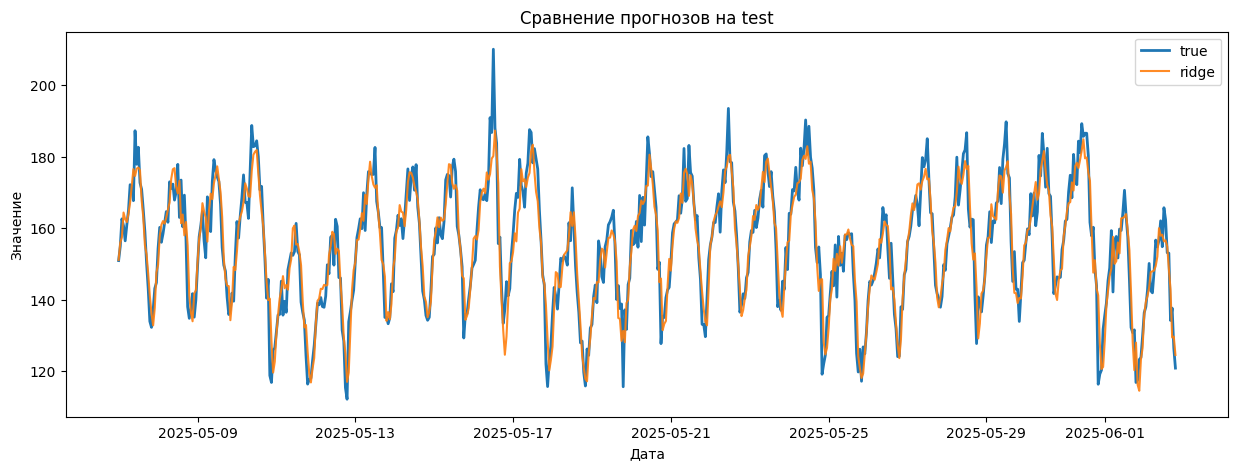

In [23]:
test_pred_ridge = ridge.predict(X_test_scaled)
test_results= regression_metrics(y_test, test_pred_ridge,)
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(val_df["date"][:-4], y_test, label="true", lw=2)

ax.plot(val_df["date"][:-4], test_pred_ridge, label="ridge", alpha=0.9)

ax.set_title("Сравнение прогнозов на test")
ax.set_xlabel("Дата")
ax.set_ylabel("Значение")
ax.legend()
plt.savefig(atrtifacts_folder+"figures/best_forecast_test.png")
plt.show()






In [24]:
test_pred_ridge = ridge.predict(X_test_scaled)

test_results= regression_metrics(y_test, val_pred_ridge)

log_csv("B3","forecasting","S12-hw-dataset.csv",RANDOM,"train_frac: float = 0.70 val_frac: float = 0.15 test_frac: float = 0.15","none",1,"Ridge"," dayofweek, month,dow_sin, dow_cos,month_sin, month_cos,lag_1, lag_2, lag_3, lag_7, lag_14, lag_28,rolling_mean_7, rolling_std_7, rolling_mean_28, rolling_std_28   ","StandartScaler","none","none",{"train_loss":[]},"none","none","none","",test_results["MAE"],test_results["RMSE"],test_results["MAPE"])